In [1]:
from src.lib.new_drivers import *
from serial.tools import list_ports
import time
from matplotlib import pyplot as plt

In [ ]:
ports = list_ports.comports()
for port in ports:
    print(port.device)

identify: *IDN?

reset: *RST

clear: *CLS

operation_complete: *OPC

zero_check_on: SYST:ZCH ON

zero_check_off: SYST:ZCH OFF

configure_current: CONF:CURR:DC

configure_resistance: CONF:RES

format_elements: FORM:ELEM READ,TST

reset_time: SYST:TST:REL:RES

query_zero_check: SYST:ZCH?


Testa il finto elettrometro.

Il led viene acceso o spento in base al valore dello zero check.

Il valore di resistenza letto è impostato dal potenziometro.

Il bottone cambia un flag interno "sending_extra_msg", che controlla se inviamo un "OK" dopo comandi che non restituiscono nulla e un "ERROR" quando ci sono errori. Quando premi il bottone, lampeggia due volte il led se ha impostato a true il flag, una volta se lo ha messo a false. Il flag è inizialmente a false (ci sono un po' di delay nella funzione che gestisce il bottone, quindi meglio dargli circa 1 secondo dopo aver premuto).

In [3]:
selected_port = "/dev/ttyUSB0"
elettrometro = ElettrometroKeithley(selected_port)

commands = elettrometro.commands

def query(cmd):
    response = elettrometro.query(cmd)
    if response is not None and response != "":
        print(response)

query(commands["identify"])

query(commands["reset"])

query(commands["operation_complete"])

query(commands["zero_check_off"])

query(commands["configure_current"])

for i in range(1):
    query("READ?")

elettrometro.close()

KEITHLEY INSTRUMENTS INC.,MODEL 6517A,0776906,C02  /A02
-00.22098E-12NADC,+0000409.664947secs,+00685rdng#


Time buffer: deque([0.000407, 0.255787, 0.494996, 0.733374, 0.972731, 1.212307, 1.450128, 1.689233, 1.92823, 2.168563, 2.406392, 2.645445, 2.884336, 3.1246, 3.363435, 3.603592, 3.841425, 4.081763, 4.321659, 4.567369])
Resistance buffer: deque([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])


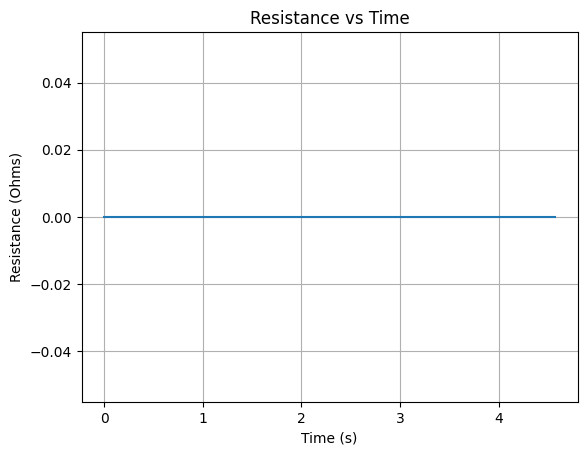

In [4]:
selected_port = "/dev/ttyUSB0"

elettrometro = ElettrometroKeithley(selected_port)

elettrometro.set_zero_check(False)

elettrometro.init_resistance_reading()

#t = elettrometro.get_fresh_reading()

#res, time_sec = elettrometro.parse_resistance_reading(t)

#print("Raw reading:", t)
#print(f"Resistance: {res} Ohms, Time: {time_sec} seconds")

#print(elettrometro.parse_resistance_reading(elettrometro.get_fresh_reading()))

#elettrometro.init_resistance_reading()

elettrometro.start_continuous_read()

time.sleep(5)

elettrometro.stop_continuous_read()

elettrometro.close()

print("Time buffer:", elettrometro.time_buffer)
print("Resistance buffer:", elettrometro.read_buffer)

plt.plot(elettrometro.time_buffer, elettrometro.read_buffer)
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.title("Resistance vs Time")
plt.grid()
plt.show()